In [2]:
import pyodbc

# Parámetros de conexión
server = 'LAPTOP-BM5H5C0O'  # o el nombre de tu instancia
database = 'Tareas'
username = 'LAPTOP-BM5H5C0O\Juan Gonzalez'  # si usas autenticación SQL
#password = 'tu_contraseña'  # si usas autenticación SQL

# Conexión (ajusta si usas autenticación de Windows)
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    f'SERVER={server};'
    f'DATABASE={database};'
    'Trusted_Connection=yes;'  # Usa esto si es autenticación de Windows
    # Usa esto si es autenticación SQL:
    # f'UID={username};PWD={password}'
)

# Crear cursor
cursor = conn.cursor()

# Prueba de consulta
cursor.execute("SELECT TOP 5 * FROM DelitosMensuales")
rows = cursor.fetchall()

for row in rows:
    print(row)

# Cerrar conexión
cursor.close()
conn.close()


(2024, 1, 'Aguascalientes', 1001, 'Aguascalientes', 'La vida y la Integridad corporal', 'Homicidio', 'Homicidio doloso', 'Con arma de fuego', 0, 1, 3, 1, 10, 4, 6, 1, 2, 4, 0, 1)
(2024, 1, 'Aguascalientes', 1001, 'Aguascalientes', 'La vida y la Integridad corporal', 'Homicidio', 'Homicidio doloso', 'Con arma blanca', 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1)
(2024, 1, 'Aguascalientes', 1001, 'Aguascalientes', 'La vida y la Integridad corporal', 'Homicidio', 'Homicidio doloso', 'Con otro elemento', 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1)
(2024, 1, 'Aguascalientes', 1001, 'Aguascalientes', 'La vida y la Integridad corporal', 'Homicidio', 'Homicidio doloso', 'No especificado', 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0)
(2024, 1, 'Aguascalientes', 1001, 'Aguascalientes', 'La vida y la Integridad corporal', 'Homicidio', 'Homicidio culposo', 'Con arma de fuego', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)


In [3]:
# Instalar si no tienes sqlite3 y pandas
# pip install pandas sqlalchemy

import pandas as pd
import sqlite3
from sqlalchemy import create_engine


c:\Users\ego_2\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# Crear una conexión con SQLite (base de datos local en archivo .db)
engine = create_engine('sqlite:///delitos_mexico.db')
conn = engine.connect()


In [5]:
# Cargar el CSV
df = pd.read_csv('C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\SQL\\2024.csv')

# Revisar columnas
print(df.columns)

# Limpiar nombres de columnas (quitar espacios, reemplazar tildes, etc.)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '').str.lower()

# Convertir de wide a long (un registro por mes)
meses = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 
         'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']

df_long = df.melt(
    id_vars=['año', 'clave_ent', 'entidad', 'cve_municipio', 'municipio', 
             'bien_jurídico_afectado', 'tipo_de_delito', 'subtipo_de_delito', 'modalidad'],
    value_vars=meses,
    var_name='mes',
    value_name='num_delitos'
)

# Crear columna fecha (año-mes) usando números de mes
mes_to_num = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
    'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}
df_long['fecha'] = pd.to_datetime(
    df_long['año'].astype(str) + '-' + df_long['mes'].map(mes_to_num),
    format='%Y-%m'
)

# Rellenar valores nulos
df_long['num_delitos'] = pd.to_numeric(df_long['num_delitos'], errors='coerce').fillna(0).astype(int)


Index(['Año', 'Clave_Ent', 'Entidad', 'Cve. Municipio', 'Municipio',
       'Bien jurídico afectado', 'Tipo de delito', 'Subtipo de delito',
       'Modalidad', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
       'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype='object')


In [6]:
# Guardar en base de datos
df_long.to_sql('delitos', con=conn, if_exists='replace', index=False)


7698960

In [7]:
query_a = """
SELECT municipio, strftime('%Y-%m', fecha) as año_mes, AVG(num_delitos) as promedio_delitos
FROM delitos
GROUP BY municipio, año_mes
ORDER BY promedio_delitos DESC
LIMIT 10;
"""
pd.read_sql(query_a, conn)


,municipio,año_mes,promedio_delitos
0,Tijuana,2024-04,49.173469
1,León,2024-05,46.479592
2,Tijuana,2024-01,46.265306
3,Tijuana,2024-05,45.826531
4,León,2024-07,45.081633
5,Tijuana,2024-03,44.806122
6,León,2024-08,44.724490
7,Tijuana,2024-02,44.357143
8,León,2024-10,43.693878
9,León,2024-09,43.367347


In [8]:
#query_b = """
#SELECT municipio, subtipo_de_delito, SUM(num_delitos) as total
#FROM delitos
#GROUP BY municipio, subtipo_de_delito
#HAVING total = (
 #   SELECT MAX(total_sub)
  #  FROM (
   ##     SELECT municipio as mun, subtipo_de_delito as sub, SUM(num_delitos) as total_sub
 #       FROM delitos d2
  #      WHERE d2.municipio = delitos.municipio
   #     GROUP BY subtipo_de_delito
    #)
#)
#"""
#pd.read_sql(query_b, conn)


In [9]:
query_b = """
WITH delitos_sumados AS (
    SELECT 
        municipio, 
        subtipo_de_delito, 
        SUM(num_delitos) AS total,
        ROW_NUMBER() OVER(PARTITION BY municipio ORDER BY SUM(num_delitos) DESC) AS rn
    FROM delitos
    GROUP BY municipio, subtipo_de_delito
)
SELECT municipio, subtipo_de_delito, total
FROM delitos_sumados
WHERE rn = 1
"""

df_delito_comun = pd.read_sql(query_b, conn)
df_delito_comun.head()


,municipio,subtipo_de_delito,total
0,Abalá,Fraude,2
1,Abasolo,Violencia familiar,532
2,Abejones,Otros delitos contra el patrimonio,3
3,Acacoyagua,Amenazas,24
4,Acajete,Violencia familiar,274


In [10]:
#ordenamos delito comun por subtipo de delito y total de delitos
df_delito_comun.sort_values(by=['total'], ascending=[False], inplace=True)

In [11]:
df_delito_comun

,municipio,subtipo_de_delito,total
854,León,Narcomenudeo,46014
803,Juárez,Violencia familiar,28956
2110,Toluca,Otros delitos del Fuero Común,23955
509,Ecatepec de Morelos,Otros delitos del Fuero Común,21006
1085,Pachuca de Soto,Otros delitos del Fuero Común,20403
...,...,...,...
1412,San Juan Yatzona,Violencia familiar,0
295,Chankom,Violencia familiar,0
276,Cenotillo,Violencia familiar,0
1466,San Mateo Sindihui,Violencia familiar,0


In [12]:
#temporada con mas crimenes agrupado por trimestre
query_c = """
SELECT 
    strftime('%Y', fecha) as año,
    ((CAST(strftime('%m', fecha) as int) - 1) / 3 + 1) as trimestre,
    SUM(num_delitos) as total
FROM delitos
GROUP BY año, trimestre
ORDER BY total DESC
LIMIT 10;
"""
pd.read_sql(query_c, conn)


,año,trimestre,total
0,2024,2,1504877
1,2024,1,1445007
2,2024,3,1438175
3,2024,4,1365237


In [13]:
#Número promedio de delitos por tipo de delito en CDMX
query_d = """
SELECT tipo_de_delito, strftime('%Y-%m', fecha) as año_mes, AVG(num_delitos) as promedio
FROM delitos
WHERE entidad LIKE '%Ciudad de México%'
GROUP BY tipo_de_delito, año_mes
ORDER BY promedio DESC
LIMIT 10;
"""
pd.read_sql(query_d, conn)


,tipo_de_delito,año_mes,promedio
0,Violencia familiar,2024-05,215.941176
1,Violencia familiar,2024-03,201.647059
2,Violencia familiar,2024-04,195.411765
3,Violencia familiar,2024-06,189.764706
4,Violencia familiar,2024-07,178.411765
5,Violencia familiar,2024-08,174.647059
6,Violencia familiar,2024-09,173.764706
7,Violencia familiar,2024-02,166.647059
8,Violencia familiar,2024-11,164.529412
9,Violencia familiar,2024-10,163.117647


In [14]:
#Análisis propio: top municipios con más delitos totales
query_e = """
SELECT municipio, SUM(num_delitos) as total
FROM delitos
GROUP BY municipio
ORDER BY total DESC
LIMIT 10;
"""
pd.read_sql(query_e, conn)


,municipio,total
0,León,150621
1,Tijuana,140127
2,Juárez,125475
3,Ecatepec de Morelos,113496
4,Cuauhtémoc,112506
5,Benito Juárez,105196
6,Guadalajara,104136
7,Mexicali,103650
8,Toluca,101643
9,Aguascalientes,95004


In [15]:
# Cargar el CSV
df = pd.read_csv('C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\SQL\\2024.csv')

# Revisar columnas
print(df.columns)


Index(['Año', 'Clave_Ent', 'Entidad', 'Cve. Municipio', 'Municipio',
       'Bien jurídico afectado', 'Tipo de delito', 'Subtipo de delito',
       'Modalidad', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
       'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype='object')


In [16]:
vehiculos_subtipos = [
    "robo de vehiculo automotor",
    "robo de autopartes",
    "robo a transportista",
    "robo en transporte individual"
]

# Filtrar DataFrame usando el nombre correcto de la columna
vehiculo_df = df[df['Subtipo de delito'].str.lower().isin([x.lower() for x in vehiculos_subtipos])]


In [17]:
#Vista 1: Total de delitos por municipio (relacionados con vehículos)
vista1 = vehiculo_df.groupby('Municipio')[['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']].sum()
vista1['total_delitos'] = vista1.sum(axis=1)
vista1 = vista1.reset_index().sort_values(by='total_delitos', ascending=False)
print(vista1[['Municipio', 'total_delitos']].head(10))



                Municipio  total_delitos
453            Cuauhtémoc           8208
2110               Toluca           6030
202         Benito Juárez           5136
1008  Naucalpan de Juárez           4683
509   Ecatepec de Morelos           4359
1143               Puebla           4318
2077  Tlalnepantla de Baz           3936
459    Cuautitlán Izcalli           3813
595           Guadalajara           3351
610     Gustavo A. Madero           3117


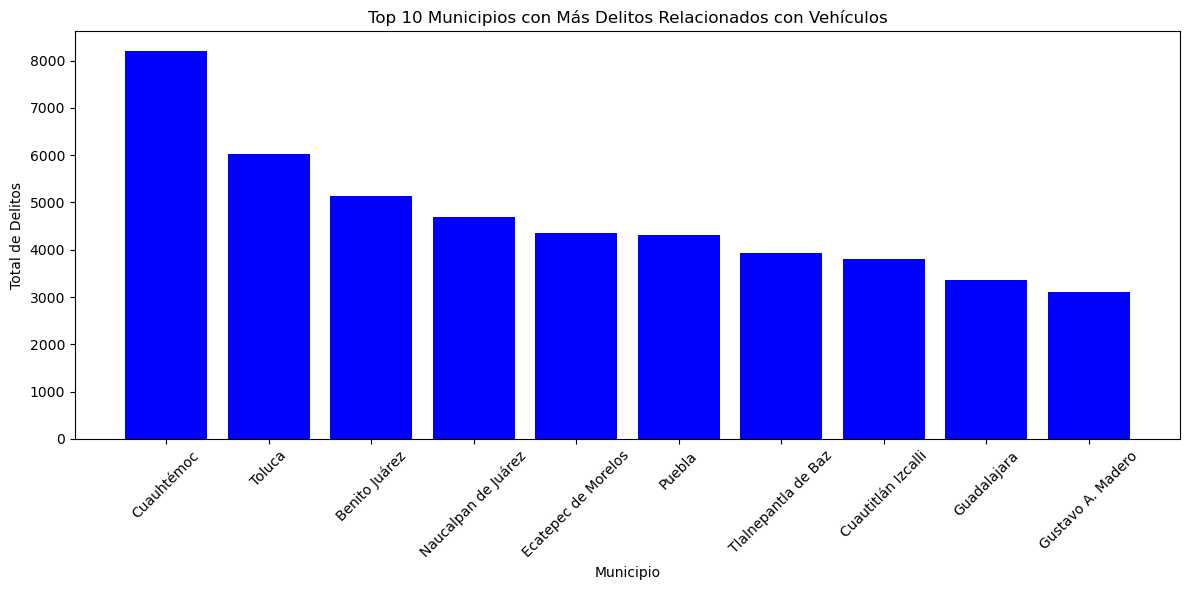

In [18]:
#vamos a crear una grafica de barras con los 10 municipios con mas delitos relacionados con vehiculos
import matplotlib.pyplot as plt
# Gráfico de barras de los 10 municipios con más delitos relacionados con vehículos
plt.figure(figsize=(12, 6))
plt.bar(vista1['Municipio'][:10], vista1['total_delitos'][:10], color='blue')
plt.title('Top 10 Municipios con Más Delitos Relacionados con Vehículos')
plt.xlabel('Municipio')
plt.ylabel('Total de Delitos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ego_2\AppData\Local\Temp\ipykernel_25192\1150299074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehiculo_df['total_delitos'] = vehiculo_df[


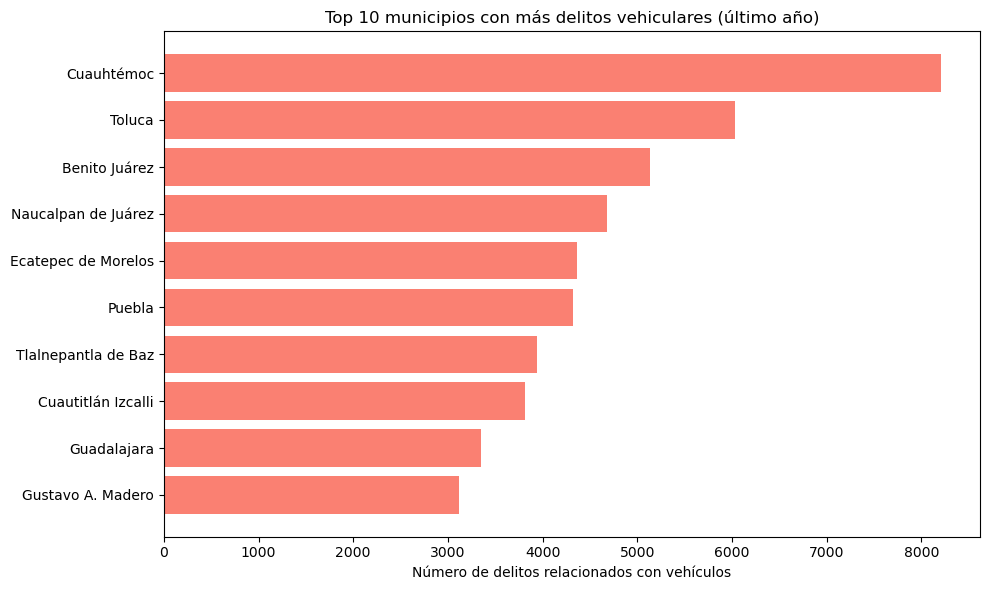

In [19]:
# Sumar los delitos por municipio para el último año disponible
ultimo_anio = vehiculo_df['Año'].max()
vehiculo_df['total_delitos'] = vehiculo_df[
    ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
].sum(axis=1)

top_municipios = (
    vehiculo_df[vehiculo_df['Año'] == ultimo_anio]
    .groupby('Municipio')['total_delitos']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_municipios['Municipio'], top_municipios['total_delitos'], color='salmon')
plt.xlabel('Número de delitos relacionados con vehículos')
plt.title('Top 10 municipios con más delitos vehiculares (último año)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [20]:
# Convertir vehiculo_df a formato largo para tener columnas 'Municipio', 'mes', 'num_delitos'
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

vehiculo_long = vehiculo_df.melt(
	id_vars=['Municipio'],
	value_vars=meses,
	var_name='mes',
	value_name='num_delitos'
)

vista2 = vehiculo_long.groupby(['Municipio', 'mes'])['num_delitos'].sum().reset_index()
vista2_pivot = vista2.pivot(index='Municipio', columns='mes', values='num_delitos').fillna(0)
print(vista2_pivot.head())


mes         Abril  Agosto  Diciembre  Enero  Febrero  Julio  Junio  Marzo  \
Municipio                                                                   
Abalá           0       0          0      0        0      0      0      0   
Abasolo         0       0          0      0        0      0      0      0   
Abejones        0       0          0      0        0      0      0      0   
Acacoyagua      0       0          0      0        0      0      0      0   
Acajete        14      10          2     16        8      2      0      2   

mes         Mayo  Noviembre  Octubre  Septiembre  
Municipio                                         
Abalá          0          0        0           0  
Abasolo        0          0        0           0  
Abejones       0          0        0           0  
Acacoyagua     0          0        0           0  
Acajete        4          6        4           6  


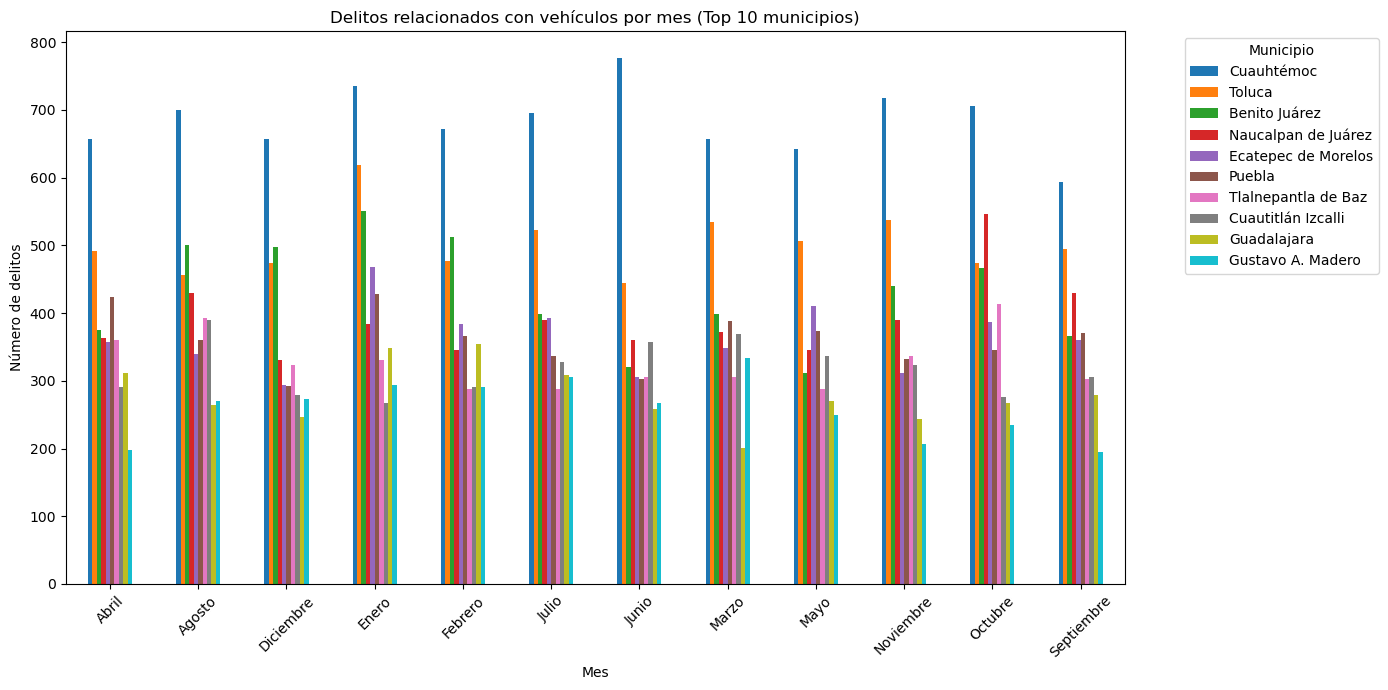

In [21]:
# Seleccionar los 10 municipios con más delitos relacionados con vehículos
top10_municipios = vista1['Municipio'][:10]

# Filtrar vista2_pivot para esos municipios
vista2_top10 = vista2_pivot.loc[top10_municipios]

# Graficar
import matplotlib.pyplot as plt

vista2_top10.T.plot(kind='bar', figsize=(14, 7))
plt.title('Delitos relacionados con vehículos por mes (Top 10 municipios)')
plt.xlabel('Mes')
plt.ylabel('Número de delitos')
plt.xticks(rotation=45)
plt.legend(title='Municipio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [22]:
vista3 = vehiculo_df.groupby(['Municipio', 'Subtipo de delito'])['total_delitos'].sum().reset_index()
vista3 = vista3.sort_values(by='total_delitos', ascending=False)
print(vista3.head(15))


                Municipio              Subtipo de delito  total_delitos
1360           Cuauhtémoc             Robo de autopartes           7794
607         Benito Juárez             Robo de autopartes           4854
6332               Toluca  Robo en transporte individual           4116
1786          Guadalajara             Robo de autopartes           3258
1831    Gustavo A. Madero             Robo de autopartes           2865
1318             Coyoacán             Robo de autopartes           2817
1379   Cuautitlán Izcalli  Robo en transporte individual           2517
3430               Puebla             Robo de autopartes           2500
3026  Naucalpan de Juárez  Robo en transporte individual           2322
1529  Ecatepec de Morelos  Robo en transporte individual           2322
6568  Venustiano Carranza             Robo de autopartes           1983
2848       Miguel Hidalgo             Robo de autopartes           1821
6233  Tlalnepantla de Baz  Robo en transporte individual        

In [23]:
# Paso 1: Diccionario de pesos
pesos = {
    'robo de vehículo automotor': 3,
    'robo de autopartes': 2,
    'robo a transportista': 3,
    'robo en transporte individual': 1
}

# Paso 2: Convertimos el subtipo a minúsculas para evitar errores de coincidencia
vehiculo_df['Subtipo de delito'] = vehiculo_df['Subtipo de delito'].str.lower()

# Paso 3: Sumar delitos anuales por municipio y subtipo
vehiculo_df['total_anual'] = vehiculo_df[['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                                          'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']].sum(axis=1)

# Paso 4: Agrupar
agrupado = vehiculo_df.groupby(['Municipio', 'Subtipo de delito'])['total_anual'].sum().reset_index()

# Paso 5: Aplicar peso y calcular el índice de riesgo
agrupado['peso'] = agrupado['Subtipo de delito'].map(pesos)
agrupado['riesgo_ponderado'] = agrupado['total_anual'] * agrupado['peso']

# Paso 6: Calcular índice de riesgo total por municipio
indice_riesgo = agrupado.groupby('Municipio')['riesgo_ponderado'].sum().reset_index()
indice_riesgo = indice_riesgo.sort_values(by='riesgo_ponderado', ascending=False)

# Mostrar top 10 municipios con mayor riesgo
print(indice_riesgo.head(10))


                Municipio  riesgo_ponderado
453            Cuauhtémoc             16014
202         Benito Juárez             10020
2110               Toluca              8553
1008  Naucalpan de Juárez              8406
1143               Puebla              8074
509   Ecatepec de Morelos              7479
2077  Tlalnepantla de Baz              7107
595           Guadalajara              6675
610     Gustavo A. Madero              6030
459    Cuautitlán Izcalli              5883


C:\Users\ego_2\AppData\Local\Temp\ipykernel_25192\289899092.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehiculo_df['Subtipo de delito'] = vehiculo_df['Subtipo de delito'].str.lower()
C:\Users\ego_2\AppData\Local\Temp\ipykernel_25192\289899092.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vehiculo_df['total_anual'] = vehiculo_df[['Enero','Febrero','Marzo','Abril','Mayo','Junio',


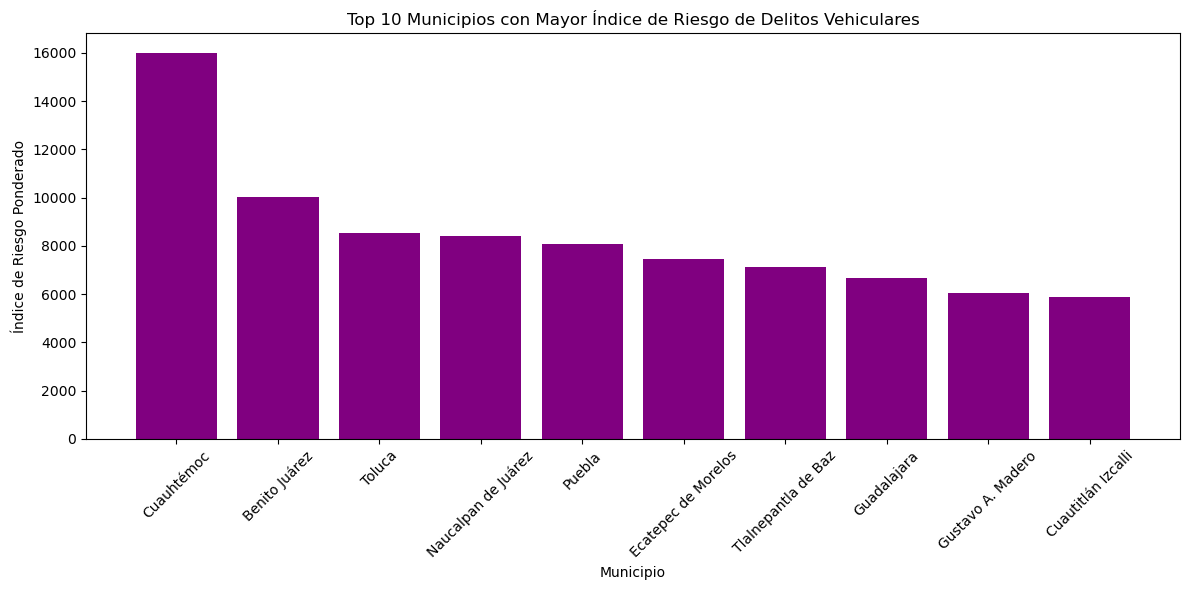

In [24]:
#grafica del indice_riesgo
plt.figure(figsize=(12, 6))
plt.bar(indice_riesgo['Municipio'][:10], indice_riesgo['riesgo_ponderado'][:10], color='purple')
plt.title('Top 10 Municipios con Mayor Índice de Riesgo de Delitos Vehiculares')
plt.xlabel('Municipio')
plt.ylabel('Índice de Riesgo Ponderado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Conclusiones del índice de riesgo
Municipios con mayor riesgo:

Cuauhtémoc, CDMX, encabeza el ranking con un riesgo ponderado de 16,014, lo que sugiere una alta incidencia de delitos graves contra vehículos.

Le siguen Benito Juárez, Toluca y Naucalpan de Juárez, todos con índices superiores a 8,000.

Alta concentración en áreas urbanas:

La mayoría de los municipios con más riesgo pertenecen a grandes zonas metropolitanas como CDMX, Edomex, Puebla y Guadalajara.

Implicaciones para aseguradoras:

Estos municipios podrían considerarse zonas de alta prima de riesgo, lo que justifica políticas de precio más altas o medidas de prevención adicionales.



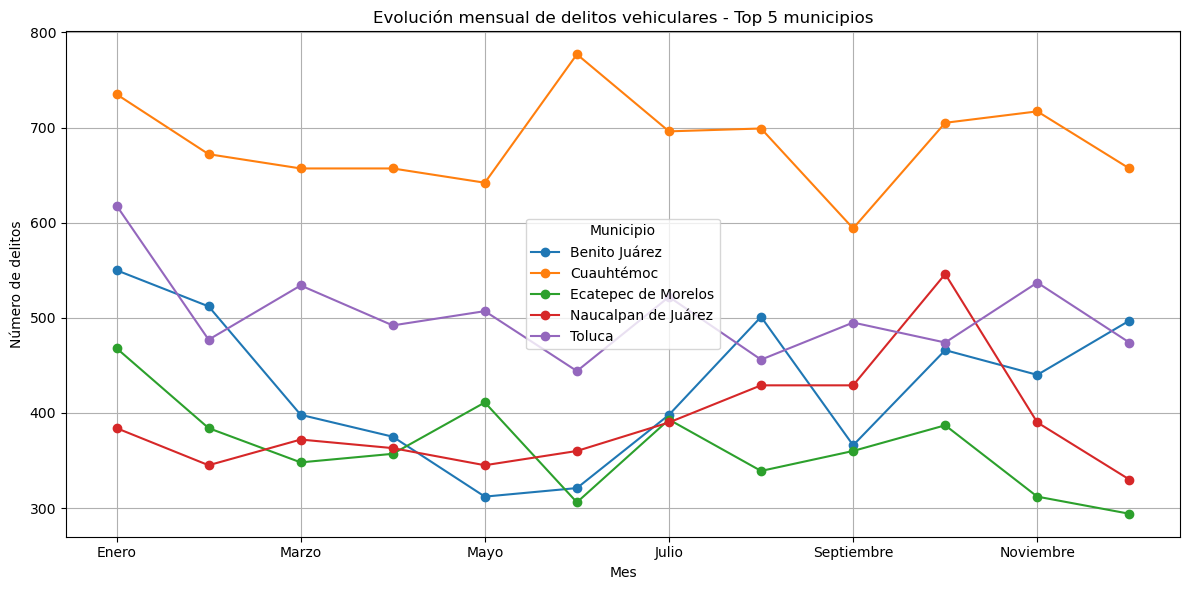

In [25]:
import matplotlib.pyplot as plt

# Seleccionamos los 5 municipios con más delitos
top_municipios = vista1.head(5)['Municipio']

# Filtramos el DataFrame original
vehiculo_top5 = vehiculo_df[vehiculo_df['Municipio'].isin(top_municipios)]

# Agrupamos por municipio y sumamos los delitos mensuales
mensual = vehiculo_top5.groupby('Municipio')[['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                                               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']].sum().T

# Gráfico de líneas
mensual.plot(figsize=(12,6), marker='o')
plt.title('Evolución mensual de delitos vehiculares - Top 5 municipios')
plt.xlabel('Mes')
plt.ylabel('Número de delitos')
plt.grid(True)
plt.legend(title='Municipio')
plt.tight_layout()
plt.show()


In [26]:
# Agrupamos por entidad y municipio
municipios_total = vehiculo_df.groupby(['Entidad', 'Municipio'])[['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                                                                   'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']].sum()

municipios_total['Total_municipio'] = municipios_total.sum(axis=1)

# Total por entidad
entidades_total = vehiculo_df.groupby('Entidad')[['Enero','Febrero','Marzo','Abril','Mayo','Junio',
                                                  'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']].sum()

entidades_total['Total_entidad'] = entidades_total.sum(axis=1)

# Convertimos a DataFrame para merge
municipios_total = municipios_total.reset_index()
entidades_total = entidades_total[['Total_entidad']].reset_index()

# Merge y cálculo del porcentaje
comparacion = pd.merge(municipios_total, entidades_total, on='Entidad')
comparacion['Porcentaje_municipio'] = (comparacion['Total_municipio'] / comparacion['Total_entidad']) * 100

# Mostramos los municipios con mayor proporción de delitos en su estado
comparacion_top = comparacion.sort_values(by='Porcentaje_municipio', ascending=False).head(10)
print(comparacion_top[['Entidad', 'Municipio', 'Porcentaje_municipio']])


                  Entidad           Municipio  Porcentaje_municipio
2348              Yucatán     Dzilam González            100.000000
17        Baja California             Tijuana             91.746032
0          Aguascalientes      Aguascalientes             82.154341
1819            Querétaro           Querétaro             75.995575
963               Nayarit               Tepic             74.468085
1900              Sinaloa            Culiacán             72.413793
288                Colima          Manzanillo             72.222222
1864      San Luis Potosí     San Luis Potosí             70.236439
377              Guerrero  Acapulco de Juárez             65.116279
19    Baja California Sur              La Paz             60.000000


Conclusiones Clave del Análisis de Riesgo por Municipio:
Municipios con Mayor Riesgo Absoluto

Cuauhtémoc (CDMX) y Benito Juárez lideran el total de delitos relacionados con vehículos, lo cual implica un alto riesgo asegurador. Se recomienda establecer tarifas más elevadas o políticas de control más estrictas en estas zonas.

Tendencia Mensual de Crímenes

El comportamiento mensual muestra picos en ciertos meses, lo que podría asociarse a estacionalidad del crimen. Esto permite prever momentos del año con mayor riesgo y ajustar estrategias de seguridad.

Concentración de Delitos por Entidad

Algunos municipios concentran más del 70% de los delitos de su estado, como Dzilam González (Yucatán) con el 100%, Tijuana (BC) con el 91.7% y Aguascalientes con el 82.1%. Esto sugiere que el riesgo no está uniformemente distribuido, y que en algunos casos basta con focalizar la atención en una sola ciudad.

In [28]:
# Instalar fpdf si no está instalado
%pip install fpdf

#exportar este archivo a pdf
from fpdf import FPDF
class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, 'Delitos Vehiculares en México - Análisis', 0, 1, 'C')

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Página {self.page_no()}', 0, 0, 'C')
    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(4)
    def chapter_body(self, body):
        self.set_font('Arial', '', 12)
        self.multi_cell(0, 10, body)
        self.ln()
    def add_table(self, df):
        self.set_font('Arial', 'B', 10)
        col_widths = [self.get_string_width(col) + 4 for col in df.columns]
        for col in df.columns:
            self.cell(col_widths[df.columns.get_loc(col)], 10, col, border=1, align='C')
        self.ln()

        self.set_font('Arial', '', 10)
        for index, row in df.iterrows():
            for col in df.columns:
                self.cell(col_widths[df.columns.get_loc(col)], 10, str(row[col]), border=1, align='C')
            self.ln()
pdf = PDF()
pdf.add_page()
pdf.chapter_title('Análisis de Delitos en México')
pdf.chapter_body('Este informe presenta un análisis de los delitos vehiculares en México, incluyendo los municipios con más delitos, los tipos de delitos más comunes y las tendencias mensuales.')
pdf.chapter_title('Top 10 Municipios con Más Delitos Vehiculares')
pdf.add_table(vista1[['Municipio', 'total_delitos']].head(10))
pdf.chapter_title('Delitos Vehiculares por Mes (Top 10 Municipios)')
pdf.add_table(vista2_top10.reset_index())
pdf.chapter_title('Delitos Vehiculares por Subtipo')
pdf.add_table(vista3.head(15))
pdf.chapter_title('Índice de Riesgo de Delitos Vehiculares')
pdf.add_table(indice_riesgo.head(10))
pdf_file_path = 'delitos_vehiculares_mexico.pdf'
pdf.output(pdf_file_path)
print(f"Informe generado: {pdf_file_path}")


Note: you may need to restart the kernel to use updated packages.
Informe generado: delitos_vehiculares_mexico.pdf
